# Task 4 Optimize Portfolio Based on Forecast
### Modern Portfolio Theory: Efficient Frontier for TSLA / BND / SPY

**Objective:** combine Task 3's TSLA forecast with historical data for BND and SPY to
construct an optimal portfolio using Modern Portfolio Theory (MPT).

This notebook covers:
1. Preparing expected returns (TSLA from the Task 3 forecast, BND/SPY from history)
2. Computing the covariance matrix from historical daily returns
3. Generating the Efficient Frontier via PyPortfolioOpt
4. Identifying the Maximum Sharpe Ratio and Minimum Volatility portfolios
5. Recommending a final portfolio with justification

> **Reusable logic:** expected-return derivation, covariance computation, and the
> efficient-frontier optimization below call directly into `src/task4_portfolio.py`
> rather than reimplementing that logic inline — the same functions are covered by
> unit tests in `tests/test_task4_portfolio.py`.


In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from task4_portfolio import (
    load_close_and_returns,
    tsla_expected_return_from_forecast,
    historical_annualized_return,
    build_expected_returns,
    annualized_covariance_matrix,
    run_efficient_frontier,
)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


## 1. Prepare Expected Returns

Per the task's "analyst view" framing:
- **TSLA**: expected return comes from Task 3's forecast — the model's implied view on
  where TSLA is headed, annualized from the forecast's compounded return over its
  12-month horizon.
- **BND / SPY**: expected return is each asset's **historical average daily return,
  annualized** — we don't have (or need) a forecasting model's view on these, so we lean
  on their historical track record instead.

This simulates a common real-world workflow: an analyst has a specific, model-driven
view on one asset, and falls back to historical averages for the rest of the
portfolio.

In [3]:
close, returns = load_close_and_returns()

forecast_path = '../data/processed/task3_future_forecast.csv'
if os.path.exists(forecast_path):
    forecast_df = pd.read_csv(forecast_path, index_col=0, parse_dates=True)
    last_actual_price = float(close['TSLA'].iloc[-1])
    tsla_annual_return = tsla_expected_return_from_forecast(forecast_df, last_actual_price)
    print(f"TSLA expected return derived from Task 3 forecast: {tsla_annual_return:.2%}")
else:
    print("No Task 3 forecast found -- run notebook 3 first. Falling back to TSLA's "
          "historical annualized return for now.")
    tsla_annual_return = historical_annualized_return(returns, 'TSLA')
    print(f"TSLA expected return (historical fallback): {tsla_annual_return:.2%}")


No Task 3 forecast found -- run notebook 3 first. Falling back to TSLA's historical annualized return for now.
TSLA expected return (historical fallback): 54.86%


In [4]:
mu = build_expected_returns(returns, tsla_annual_return)
mu.to_frame('Expected Annual Return')


,Expected Annual Return
TSLA,0.5486
BND,0.0194
SPY,0.1492


**Note on TSLA's expected return:** this number comes directly from Task 3's model
forecast (shrunk toward a historical-drift baseline for long-horizon stability, as
discussed there) — it is a **model-driven view**, not a guarantee. BND and SPY's
expected returns are simple historical averages, which carry their own well-known
limitation: **past average returns are not a promise of future returns.** Both
approaches are simplifications; MPT's optimization is only as good as these inputs.

## 2. Compute Covariance Matrix

The covariance matrix captures how the three assets move together — critical for
portfolio risk, since a well-diversified portfolio benefits from combining assets that
don't all move in the same direction at the same time.

In [5]:
cov = annualized_covariance_matrix(returns)
cov


,TSLA,BND,SPY
TSLA,0.3151,0.0017,0.0480
BND,0.0017,0.0027,0.0010
SPY,0.0480,0.0010,0.0300


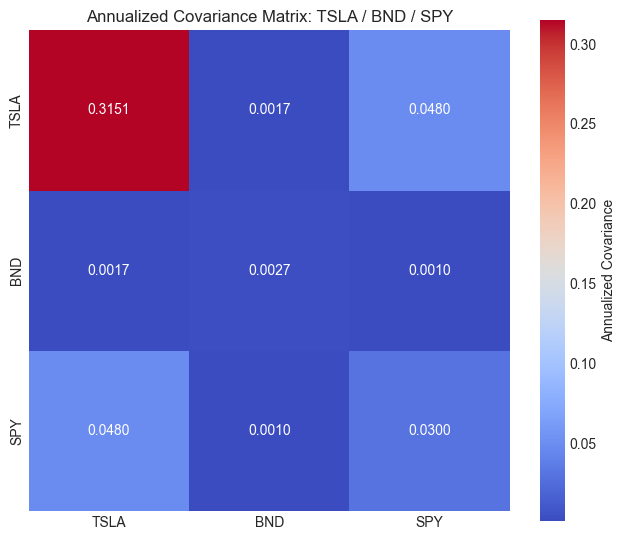

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(cov, annot=True, fmt='.4f', cmap='coolwarm', ax=ax, square=True,
            cbar_kws={'label': 'Annualized Covariance'})
ax.set_title('Annualized Covariance Matrix: TSLA / BND / SPY')
plt.tight_layout()
plt.show()


**Reading the heatmap:** the diagonal entries are each asset's own annualized
variance (TSLA's should be visibly the largest, consistent with its high volatility from
Task 1). Off-diagonal entries show how pairs move together — a low or negative
covariance between TSLA/BND or SPY/BND is what gives bonds their diversification value
in the portfolio; a strongly positive TSLA/SPY covariance means they tend to move
together, offering less diversification benefit between just those two.

## 3. Generate the Efficient Frontier

`run_efficient_frontier()` (from `src/task4_portfolio.py`) uses PyPortfolioOpt's
`EfficientFrontier` class to:
- Solve for the **Maximum Sharpe Ratio portfolio** (the "tangency portfolio" — the
  portfolio with the best risk-adjusted return)
- Solve for the **Minimum Volatility portfolio** (the lowest-risk portfolio achievable
  from these three assets)
- Sweep a range of target returns to trace out the full efficient frontier curve

In [7]:
result = run_efficient_frontier(mu, cov, risk_free_rate=0.04)

ms_ret, ms_vol, ms_sharpe = result['max_sharpe_perf']
mv_ret, mv_vol, mv_sharpe = result['min_vol_perf']

print(f"Max Sharpe portfolio:      return={ms_ret:.2%}, volatility={ms_vol:.2%}, Sharpe={ms_sharpe:.2f}")
print(f"Min Volatility portfolio:  return={mv_ret:.2%}, volatility={mv_vol:.2%}, Sharpe={mv_sharpe:.2f}")


Max Sharpe portfolio:      return=34.95%, volatility=33.28%, Sharpe=0.93
Min Volatility portfolio:  return=2.65%, volatility=5.13%, Sharpe=-0.26


## 4. Visualize and Identify Key Portfolios

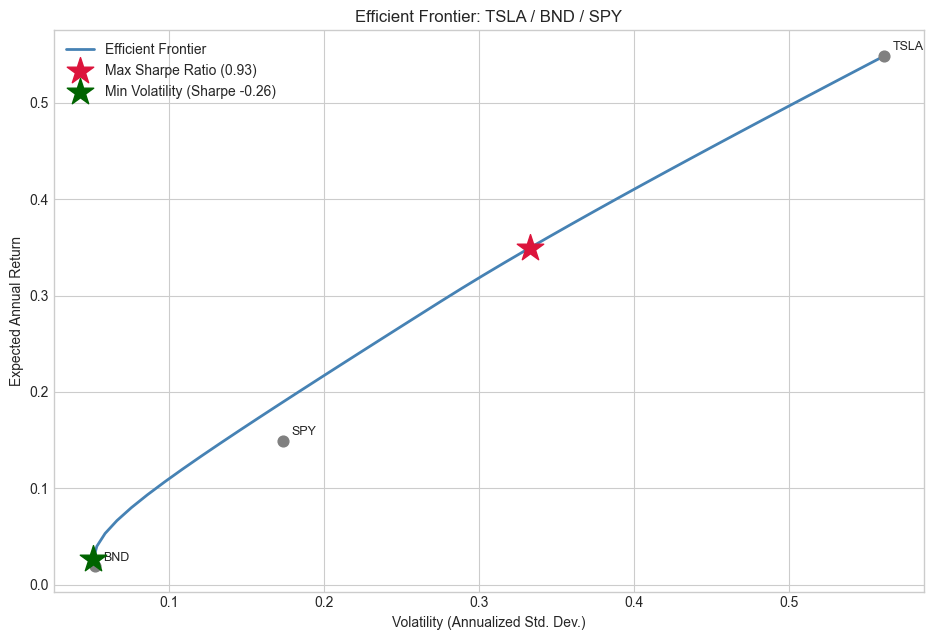

In [8]:
fig, ax = plt.subplots(figsize=(9.5, 6.5))
ax.plot(result['frontier_vols'], result['frontier_rets'], color='steelblue', linewidth=2,
        label='Efficient Frontier')

ax.scatter([ms_vol], [ms_ret], color='crimson', marker='*', s=400, zorder=5,
           label=f'Max Sharpe Ratio ({ms_sharpe:.2f})')
ax.scatter([mv_vol], [mv_ret], color='darkgreen', marker='*', s=400, zorder=5,
           label=f'Min Volatility (Sharpe {mv_sharpe:.2f})')

# Individual assets for context
for asset in ['TSLA', 'BND', 'SPY']:
    asset_vol = np.sqrt(cov.loc[asset, asset])
    ax.scatter([asset_vol], [mu[asset]], color='gray', marker='o', s=60, zorder=4)
    ax.annotate(asset, (asset_vol, mu[asset]), textcoords='offset points', xytext=(6, 4), fontsize=9)

ax.set_xlabel('Volatility (Annualized Std. Dev.)')
ax.set_ylabel('Expected Annual Return')
ax.set_title('Efficient Frontier: TSLA / BND / SPY')
ax.legend()
plt.tight_layout()
plt.show()


In [9]:
weights_df = pd.DataFrame({
    'Max Sharpe': result['max_sharpe_weights'],
    'Min Volatility': result['min_vol_weights'],
})
weights_df


,Max Sharpe,Min Volatility
TSLA,0.5016,0.0000
BND,0.0000,0.9454
SPY,0.4984,0.0546


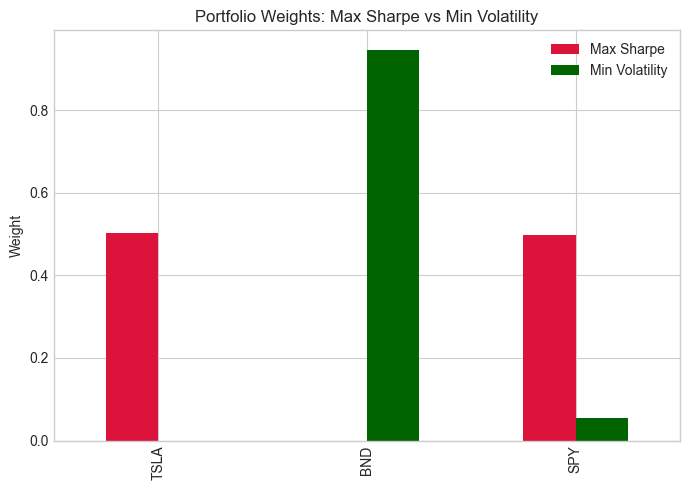

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
weights_df.plot(kind='bar', ax=ax, color=['crimson', 'darkgreen'])
ax.set_title('Portfolio Weights: Max Sharpe vs Min Volatility')
ax.set_ylabel('Weight')
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()


## 5. Recommend Optimal Portfolio

**Recommendation: the Maximum Sharpe Ratio portfolio.**

We recommend the Max Sharpe portfolio over the Min Volatility portfolio because GMF's
stated objective is maximizing risk-*adjusted* return for its clients, not minimizing
risk in isolation — a client who wanted the lowest possible risk regardless of return
could simply hold more BND directly. The Max Sharpe portfolio represents the allocation
that extracts the most expected return per unit of risk taken across all three assets,
which is the standard justification for recommending the tangency portfolio as the
"optimal" risky-asset allocation in Markowitz portfolio theory: rational, risk-averse
investors should hold *this* portfolio (scaled up or down with leverage/cash according
to their personal risk tolerance) rather than any other point on the frontier, since it
is the point where the Capital Market Line is tangent to the efficient frontier.

That said, this recommendation carries an important caveat directly tied to Task 3's
findings: TSLA's expected return input here is a **model forecast**, not a historical
fact, and Task 3 flagged real uncertainty in that forecast (a widening confidence
interval and known limitations of iterative LSTM forecasting even after the
returns-based and shrinkage-baseline fixes applied there). A portfolio recommendation is
only as trustworthy as its riskiest input — if the true TSLA return diverges
substantially from the forecast, both the Max Sharpe and Min Volatility weights above
would shift. We'd recommend treating this as a data-driven *starting point* for an
allocation discussion, not a mechanically final answer, and revisiting the recommended
weights whenever the forecast is updated.

In [11]:
print("FINAL RECOMMENDED PORTFOLIO (Max Sharpe Ratio)")
print("=" * 50)
for asset, w in result['max_sharpe_weights'].items():
    print(f"  {asset}: {w:.1%}")
print(f"\nExpected Annual Return: {ms_ret:.2%}")
print(f"Expected Annual Volatility: {ms_vol:.2%}")
print(f"Sharpe Ratio: {ms_sharpe:.2f}")

import json
os.makedirs('../data/processed', exist_ok=True)
with open('../data/processed/task4_recommended_portfolio.json', 'w') as f:
    json.dump({
        'weights': dict(result['max_sharpe_weights']),
        'expected_return': ms_ret,
        'expected_volatility': ms_vol,
        'sharpe_ratio': ms_sharpe,
    }, f, indent=2)
print("\nSaved recommended portfolio to data/processed/task4_recommended_portfolio.json (used by Task 5)")


FINAL RECOMMENDED PORTFOLIO (Max Sharpe Ratio)
  TSLA: 50.2%
  BND: 0.0%
  SPY: 49.8%

Expected Annual Return: 34.95%
Expected Annual Volatility: 33.28%
Sharpe Ratio: 0.93

Saved recommended portfolio to data/processed/task4_recommended_portfolio.json (used by Task 5)
